In [83]:
import pandas as pd
import json
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns


In [84]:
books_df = pd.read_csv('./clean/books.csv', low_memory=False)
reviews_df = pd.read_csv('./clean/reviews.csv',low_memory=False)
series_df = pd.read_csv('./clean/series.csv')
books_genres_df = pd.read_csv('./clean/books_genres.csv')
users_df = pd.read_csv('./clean/users.csv')

In [85]:
print(books_df['average_rating'].unique())
print(books_df['average_rating'].head(20)) 

['[3.71]' '[4.13]' '[2.61]' '[4.34]' '[3.39]' '[3.32]' '[2.81]' '[3.67]'
 '[3.62]' '[4.09]' '[4.66]' '[4.1]' '[3.24]' '[2.94]' '[4.22]' '[3.42]'
 '[3.99]' '[3.79]' '[4.57]' '[3.57]' '[3.58]' '[4.19]' '[4.21]' '[3.63]'
 '[3.97]' '[4.43]' '[4.51]' '[4.04]' '[3.86]' '[4.41]' '[4.05]' '[4.03]'
 '[3.76]' '[3.29]' '[4.12]' '[4.18]' '[4.02]' '[4.39]' '[4.16]' '[3.66]'
 '[3.65]' '[3.9]' '[3.75]' '[3.74]' '[3.43]' '[4.47]' '[3.88]' '[3.83]'
 '[4.65]' '[4.23]' '[4.38]' '[3.82]' '[3.36]' '[3.77]' '[3.92]' '[4.31]'
 '[4.17]' '[3.47]' '[3.95]' '[3.98]' '[4.06]' '[3.85]' '[3.16]' '[3.8]'
 '[3.81]' '[3.94]' '[4.01]' '[3.69]' '[4.11]' '[4.26]' '[4.2]' '[4.4]'
 '[3.96]' '[3.84]' '[4.27]' '[3.72]' '[4.07]' '[4.37]' '[4.25]' '[4.15]'
 '[4.24]' '[3.93]' '[4.28]' '[3.1]' '[3.91]' '[3.59]' '[4.55]' '[3.7]'
 '[3.6]' '[4.3]' '[4.46]' '[4.14]' '[3.68]' '[4.63]' '[3.51]' '[3.87]'
 '[3.56]' '[4.53]' '[3.23]' '[4.32]' '[3.53]' '[3.48]' '[4.45]' '[4.49]'
 '[4.5]' '[4.08]' '[3.52]' '[3.78]' '[3.49]' '[4.58]' '[3.64

In [86]:
# remove square brackets and strip any extra whitespace
books_df['average_rating'] = books_df['average_rating'].str.strip("[]").str.strip()

# convert to numeric, coercing errors to NaN
books_df['average_rating'] = pd.to_numeric(books_df['average_rating'], errors='coerce')

# drop rows where 'average_rating' is NaN after conversion
books_df = books_df.dropna(subset=['average_rating'])

print(books_df['average_rating'].unique())
print(books_df['average_rating'].head(20))

[3.71 4.13 2.61 4.34 3.39 3.32 2.81 3.67 3.62 4.09 4.66 4.1  3.24 2.94
 4.22 3.42 3.99 3.79 4.57 3.57 3.58 4.19 4.21 3.63 3.97 4.43 4.51 4.04
 3.86 4.41 4.05 4.03 3.76 3.29 4.12 4.18 4.02 4.39 4.16 3.66 3.65 3.9
 3.75 3.74 3.43 4.47 3.88 3.83 4.65 4.23 4.38 3.82 3.36 3.77 3.92 4.31
 4.17 3.47 3.95 3.98 4.06 3.85 3.16 3.8  3.81 3.94 4.01 3.69 4.11 4.26
 4.2  4.4  3.96 3.84 4.27 3.72 4.07 4.37 4.25 4.15 4.24 3.93 4.28 3.1
 3.91 3.59 4.55 3.7  3.6  4.3  4.46 4.14 3.68 4.63 3.51 3.87 3.56 4.53
 3.23 4.32 3.53 3.48 4.45 4.49 4.5  4.08 3.52 3.78 3.49 4.58 3.64 4.33
 3.55 3.34 4.35 4.   4.64 3.89 3.73 3.5  4.44 4.6  4.52 4.7  4.61 4.62
 2.98 3.33 3.44 4.48 4.42 4.29 3.4  4.9  4.36 3.38 3.61 3.37 3.27 3.45
 3.   3.31 3.28 3.04 3.54 3.11 3.15 4.71 4.67 4.54 4.56 4.73 3.03 3.26
 4.59 3.35 2.43 3.41 3.46 3.18 2.83 3.2  4.74 3.05 3.3  4.76 2.29 2.
 5.   2.77 3.25 3.17 4.8  2.69 2.82 3.22 3.08 2.9  2.76 3.19 2.55 3.09
 2.57 2.8  2.72 3.13 3.21 2.65 3.07 3.02 3.14 2.93 2.86 4.72 3.01 0.
 2.5  2.67 2

In [87]:
books_df

,isbn,isbn13,title,image_url,description,author,num_pages,language,review_count,kindle_price,publish_date,crawl_source,average_rating,series
0,'1662528396','9781662528392',['Cruel Winter with You'],['https://images-na.ssl-images-amazon.com/imag...,"['For two former childhood friends, a blustery...",['Ali Hazelwood'],[73],['English'],[11514],['0.99'],[1731398400000],['https://www.goodreads.com/book/show/22038945...,3.71,Under The Mistletoe Collection
1,'0664266703','9780664266707',['The Purpose Gap: Empowering Communities of C...,['https://images-na.ssl-images-amazon.com/imag...,"[""In The Purpose Gap, Patrick Reyes reflects o...",['Patrick B. Reyes'],[256],['English'],[12],['9.99'],[1615878000000],['https://www.goodreads.com/book/show/55334104...,4.13,NaN
2,'166252823X','9781662528231',['All by My Elf'],['https://images-na.ssl-images-amazon.com/imag...,"['Secret crushes, spicy Christmas treats, hein...",['Olivia Dade'],[55],['English'],[3892],['0.99'],[1731398400000],['https://www.goodreads.com/book/show/22038945...,2.61,Under The Mistletoe Collection
3,'1400341124','9781400341122',['Mostly What God Does: Reflections on Seeking...,['https://images-na.ssl-images-amazon.com/imag...,"[""Mostly what God does is love you.\r\n\r\nIf ...",['Savannah Guthrie'],[302],['English'],[726],['14.99'],[1708416000000],['https://www.goodreads.com/book/show/20021292...,4.34,NaN
4,'1662529376','9781662529375',['Only Santas in the Building'],['https://images-na.ssl-images-amazon.com/imag...,"['It’s beginning to look a lot like Christmas,...",['Alexis Daria'],[65],['English'],[3047],['0.99'],[1731398400000],['https://www.goodreads.com/book/show/22038909...,3.39,Under The Mistletoe Collection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78676,'1580625339','9781580625333',['Everything Ghost Book'],['https://images-na.ssl-images-amazon.com/imag...,"[""Ghosts and spirits have haunted houses and c...",['Jason R. Rich'],[289],['English'],[2],NaN,[996649200000],['https://www.goodreads.com/book/show/249994.E...,3.50,NaN
78677,'0879517107','9780879517106',['Everything and More'],['https://images-na.ssl-images-amazon.com/imag...,"[""“Powered by a fast-moving plot, this latest ...",['Geoff Nicholson'],[249],['English'],[5],['12.99'],[928220400000],['https://www.goodreads.com/book/show/249996.E...,3.88,NaN
78678,'158062684X','9781580626842',"[""The Everything Kids' Nature Book: Create Clo...",['https://images-na.ssl-images-amazon.com/imag...,"[""The natural world holds secrets under every ...",['Kathiann M. Kowalski'],[144],['English'],[2],['6.99'],[1014969600000],['https://www.goodreads.com/book/show/249997.T...,4.00,NaN
78679,'0226100316','9780226100319',['Improvising Theory: Process and Temporality ...,['https://images-na.ssl-images-amazon.com/imag...,['Scholars have long recognized that ethnograp...,['Allaine Cerwonka'],[203],['English'],[10],['27.99'],[1184482800000],['https://www.goodreads.com/book/show/250000.I...,4.00,NaN


In [88]:
# remove [ ]
def unlist(value):
    return value.strip("[]").strip() if isinstance(value, str) else value

for col in books_df.columns:
    books_df[col] = books_df[col].apply(unlist)

In [89]:
books_df

,isbn,isbn13,title,image_url,description,author,num_pages,language,review_count,kindle_price,publish_date,crawl_source,average_rating,series
0,'1662528396','9781662528392','Cruel Winter with You','https://images-na.ssl-images-amazon.com/image...,"'For two former childhood friends, a blustery ...",'Ali Hazelwood',73,'English',11514,'0.99',1731398400000,'https://www.goodreads.com/book/show/220389458...,3.71,Under The Mistletoe Collection
1,'0664266703','9780664266707','The Purpose Gap: Empowering Communities of Co...,'https://images-na.ssl-images-amazon.com/image...,"""In The Purpose Gap, Patrick Reyes reflects on...",'Patrick B. Reyes',256,'English',12,'9.99',1615878000000,'https://www.goodreads.com/book/show/55334104-...,4.13,NaN
2,'166252823X','9781662528231','All by My Elf','https://images-na.ssl-images-amazon.com/image...,"'Secret crushes, spicy Christmas treats, heino...",'Olivia Dade',55,'English',3892,'0.99',1731398400000,'https://www.goodreads.com/book/show/220389455...,2.61,Under The Mistletoe Collection
3,'1400341124','9781400341122','Mostly What God Does: Reflections on Seeking ...,'https://images-na.ssl-images-amazon.com/image...,"""Mostly what God does is love you.\r\n\r\nIf w...",'Savannah Guthrie',302,'English',726,'14.99',1708416000000,'https://www.goodreads.com/book/show/200212922...,4.34,NaN
4,'1662529376','9781662529375','Only Santas in the Building','https://images-na.ssl-images-amazon.com/image...,"'It’s beginning to look a lot like Christmas, ...",'Alexis Daria',65,'English',3047,'0.99',1731398400000,'https://www.goodreads.com/book/show/220389090...,3.39,Under The Mistletoe Collection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78676,'1580625339','9781580625333','Everything Ghost Book','https://images-na.ssl-images-amazon.com/image...,"""Ghosts and spirits have haunted houses and ca...",'Jason R. Rich',289,'English',2,NaN,996649200000,'https://www.goodreads.com/book/show/249994.Ev...,3.50,NaN
78677,'0879517107','9780879517106','Everything and More','https://images-na.ssl-images-amazon.com/image...,"""“Powered by a fast-moving plot, this latest e...",'Geoff Nicholson',249,'English',5,'12.99',928220400000,'https://www.goodreads.com/book/show/249996.Ev...,3.88,NaN
78678,'158062684X','9781580626842',"""The Everything Kids' Nature Book: Create Clou...",'https://images-na.ssl-images-amazon.com/image...,"""The natural world holds secrets under every r...",'Kathiann M. Kowalski',144,'English',2,'6.99',1014969600000,'https://www.goodreads.com/book/show/249997.Th...,4.00,NaN
78679,'0226100316','9780226100319','Improvising Theory: Process and Temporality i...,'https://images-na.ssl-images-amazon.com/image...,'Scholars have long recognized that ethnograph...,'Allaine Cerwonka',203,'English',10,'27.99',1184482800000,'https://www.goodreads.com/book/show/250000.Im...,4.00,NaN


In [90]:
books_genres_df


,isbn13,genre_name
0,'9781662528392',Romance
1,'9781662528392',Christmas
2,'9781662528392',Novella
3,'9781662528392',Holiday
4,'9781662528392',Audiobook
...,...,...
317555,'9781580626842',Education
317556,'9780226100319',Anthropology
317557,'9780226100319',Theory
317558,'9780140512694',History


In [91]:
# Display the unique genre names
unique_genres = books_genres_df['genre_name'].unique()

# Print the number of unique genres and their values
print(f"Number of unique genres: {len(unique_genres)}")
print("Unique genres:")
unique_genres

Number of unique genres: 1022
Unique genres:


array(['Romance', 'Christmas', 'Novella', ..., 'Medievalism',
       'Computation', 'Peer Review'], dtype=object)

In [92]:
reviews_df


,isbn,isbn13,user_id,rating_score
0,0345465296,9780345465290,1742824,5.0
1,0345465296,9780345465290,9180313,5.0
2,0345465296,9780345465290,36153170,5.0
3,0345465296,9780345465290,22819383,4.0
4,0345465296,9780345465290,8845508,5.0
...,...,...,...,...
845852,0399155341,9780399155345,125982174,5.0
845853,0439554934,9780439554930,125982174,5.0
845854,0316015849,9780316015844,125982174,5.0
845855,0062024035,9780062024039,125982174,5.0


In [93]:
series_df


,series_id,name
0,1,Port William
1,2,مدن الملح
2,3,Buck Godot
3,4,Mercy Thompson
4,5,Rachel Krall
...,...,...
5944,5945,The Hurricane Wars
5945,5946,Funny Women Write from the Road
5946,5947,Women of the West
5947,5948,Thora


In [94]:
users_df

,user_id,name,profile_url,total_ratings,total_reviews,avg_rating,image_url
0,19185877,acacia,https://www.goodreads.com/user/show/19185877-a...,835,59,4.30,https://images.gr-assets.com/users/1597698907p...
1,169105231,kelli,https://www.goodreads.com/user/show/169105231-...,384,1,3.60,https://images.gr-assets.com/users/1692562817p...
2,38623456,steph,https://www.goodreads.com/user/show/38623456-s...,365,0,3.33,https://s.gr-assets.com/assets/nophoto/user/f_...
3,8829118,mindy,https://www.goodreads.com/user/show/8829118-mi...,59,2,3.69,NaN
4,179297432,kourtney,https://www.goodreads.com/user/show/179297432-...,64,11,4.28,NaN
...,...,...,...,...,...,...,...
23587,502678,Gail,https://www.goodreads.com/user/show/502678-gail,0,0,0.00,https://i.gr-assets.com/images/S/compressed.ph...
23588,31968163,The Overflowing Inkwell,https://www.goodreads.com/user/show/31968163-t...,0,0,0.00,https://i.gr-assets.com/images/S/compressed.ph...
23589,43122073,Linda,https://www.goodreads.com/user/show/43122073-l...,0,0,0.00,https://i.gr-assets.com/images/S/compressed.ph...
23590,87271128,Khava,https://www.goodreads.com/user/show/87271128-k...,0,0,0.00,https://i.gr-assets.com/images/S/compressed.ph...


In [96]:
num_books = books_df.shape[0]
num_reviews = reviews_df.shape[0]
unique_users = users_df['user_id'].nunique() if 'user_id' in reviews_df.columns else None

reviews_per_user = num_reviews / unique_users if unique_users else None
reviews_per_book = num_reviews / num_books

# Print statistics
print(f"Number of books: {num_books}")
print(f"Number of reviews: {num_reviews}")
print(f"Number of unique users: {unique_users}")
print(f"Average reviews per user: {reviews_per_user:.2f}" if reviews_per_user else "User data not available")
print(f"Average reviews per book: {reviews_per_book:.2f}")

Number of books: 78681
Number of reviews: 845857
Number of unique users: 23570
Average reviews per user: 35.89
Average reviews per book: 10.75


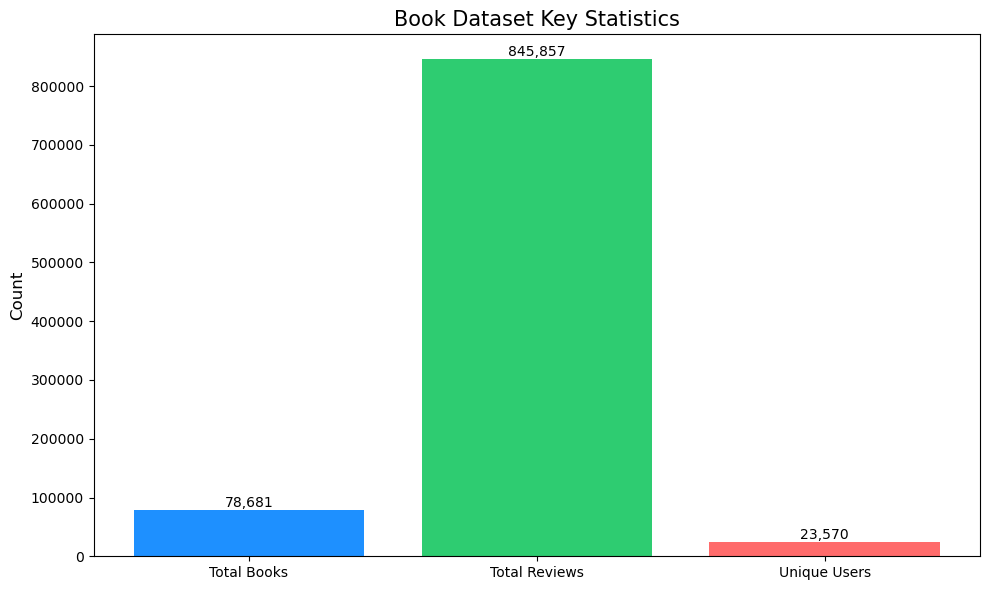

In [97]:
# Create a bar plot to visualize the key statistics
plt.figure(figsize=(10, 6))
stats = [num_books, num_reviews, unique_users]
labels = ['Total Books', 'Total Reviews', 'Unique Users']
colors = ['#1E90FF', '#2ECC71', '#FF6B6B']

plt.bar(labels, stats, color=colors)
plt.title('Book Dataset Key Statistics', fontsize=15)
plt.ylabel('Count', fontsize=12)

# Add value labels on top of each bar
for i, v in enumerate(stats):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


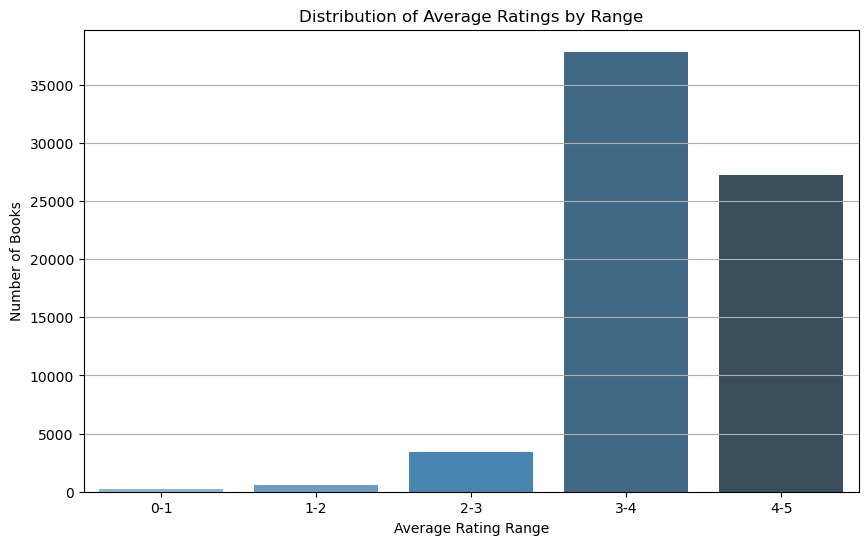

In [140]:
# Create bins for average rating ranges
rating_bins = pd.cut(books_df['average_rating'], bins=[0, 1, 2, 3, 4, 5], labels=['0-1', '1-2', '2-3', '3-4', '4-5'])

# Count the number of books in each bin
rating_range_counts = rating_bins.value_counts().sort_index()

# Plot the grouped data
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_range_counts.index, y=rating_range_counts.values, palette='Blues_d')
plt.title('Distribution of Average Ratings by Range')
plt.xlabel('Average Rating Range')
plt.ylabel('Number of Books')
plt.grid(axis='y')
plt.show()


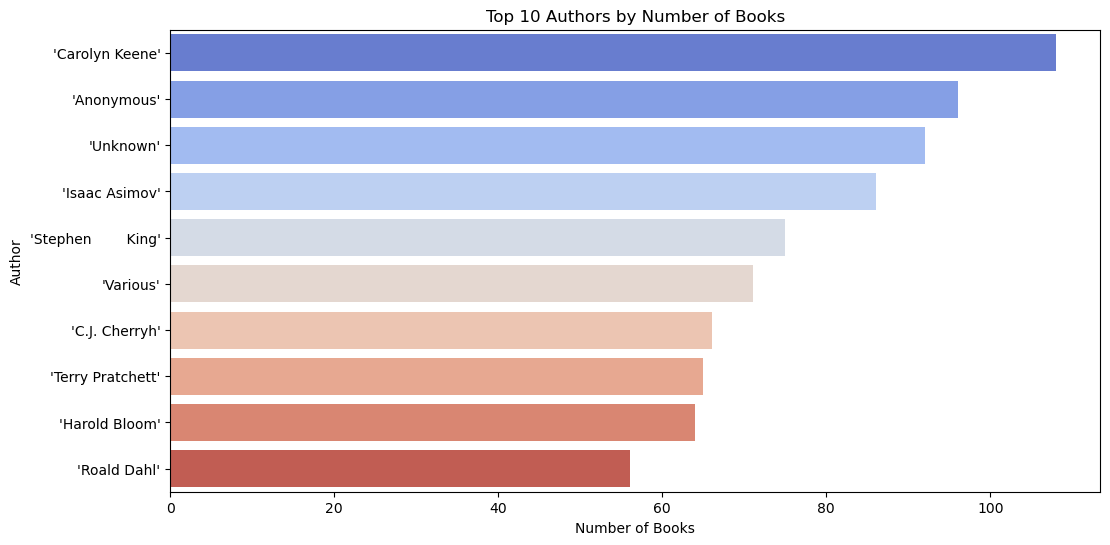

In [99]:
top_authors = books_df['author'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='coolwarm')
plt.title('Top 10 Authors by Number of Books')
plt.xlabel('Number of Books')
plt.ylabel('Author')
plt.show()


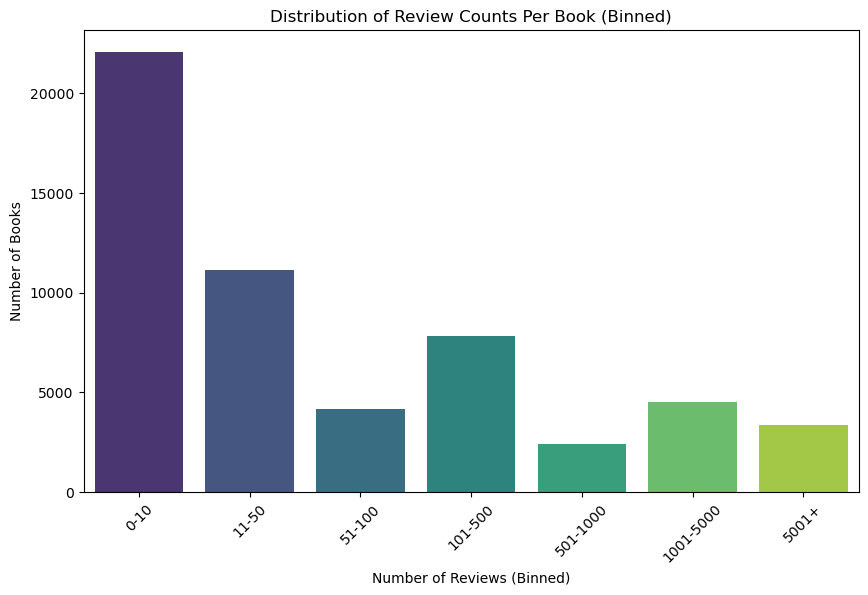

In [100]:
# clean the 'review_count' column
books_df['review_count'] = books_df['review_count'].astype(str).str.extract(r'(\d+)').astype(float)

# define bins for review counts
bins = [0, 10, 50, 100, 500, 1000, 5000, books_df['review_count'].max()]
labels = ['0-10', '11-50', '51-100', '101-500', '501-1000', '1001-5000', '5001+']

# bin the review counts and count books in each bin
books_df['review_count_bins'] = pd.cut(books_df['review_count'], bins=bins, labels=labels, right=True)
review_count_distribution = books_df['review_count_bins'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=review_count_distribution.index, y=review_count_distribution.values, palette="viridis")
plt.title('Distribution of Review Counts Per Book (Binned)')
plt.xlabel('Number of Reviews (Binned)')
plt.ylabel('Number of Books')
plt.xticks(rotation=45)
plt.show()


In [101]:
print(books_df.columns)

Index(['isbn', 'isbn13', 'title', 'image_url', 'description', 'author',
       'num_pages', 'language', 'review_count', 'kindle_price', 'publish_date',
       'crawl_source', 'average_rating', 'series', 'review_count_bins'],
      dtype='object')


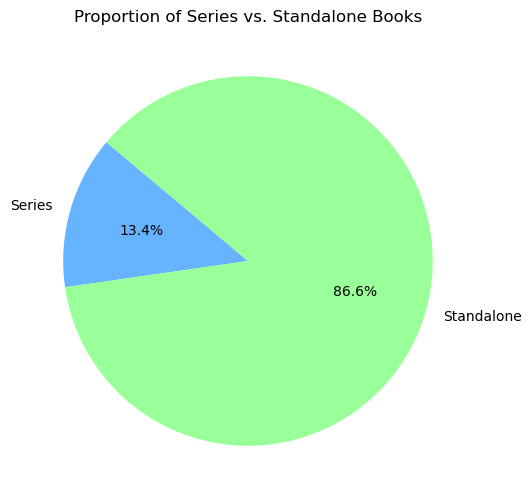

In [102]:
series_books = books_df['series'].notna().sum()
standalone_books = books_df['series'].isna().sum()

plt.figure(figsize=(8, 6))
plt.pie(
    [series_books, standalone_books],
    labels=['Series', 'Standalone'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66b3ff', '#99ff99']
)
plt.title('Proportion of Series vs. Standalone Books')
plt.show()


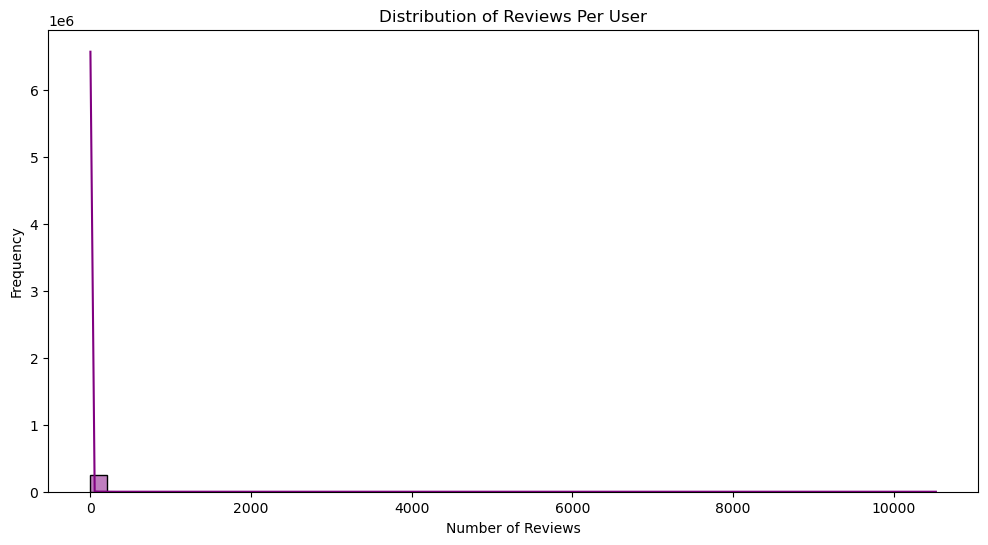

In [103]:
if 'user_id' in reviews_df.columns:
    user_reviews_count = reviews_df['user_id'].value_counts()

    plt.figure(figsize=(12, 6))
    sns.histplot(user_reviews_count, bins=50, kde=True, color='purple')
    plt.title('Distribution of Reviews Per User')
    plt.xlabel('Number of Reviews')
    plt.ylabel('Frequency')
    plt.show()


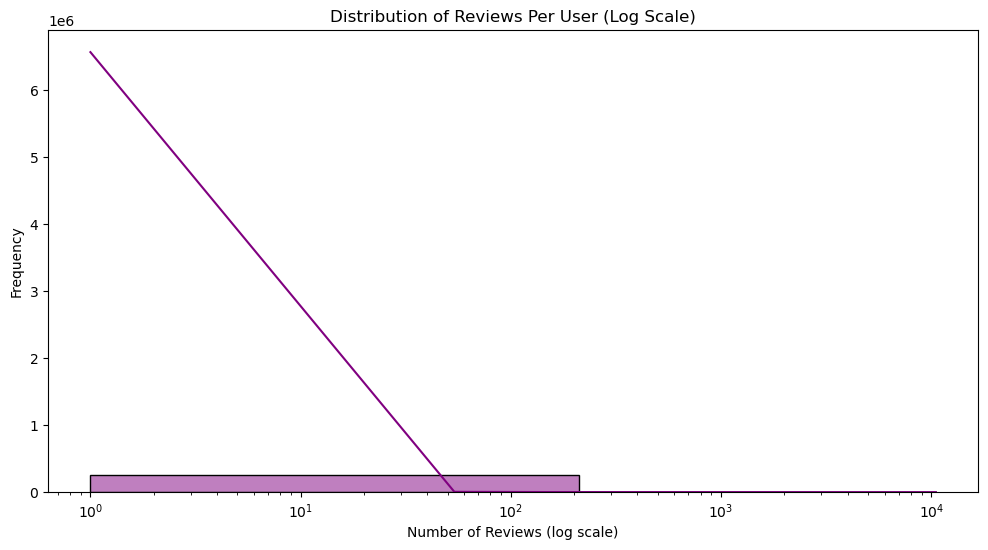

In [104]:
if 'user_id' in reviews_df.columns:
    user_reviews_count = reviews_df['user_id'].value_counts()

    plt.figure(figsize=(12, 6))
    sns.histplot(user_reviews_count, bins=50, kde=True, color='purple')
    
    # Set the x-axis to a logarithmic scale
    plt.xscale('log')
    
    plt.title('Distribution of Reviews Per User (Log Scale)')
    plt.xlabel('Number of Reviews (log scale)')
    plt.ylabel('Frequency')
    plt.show()


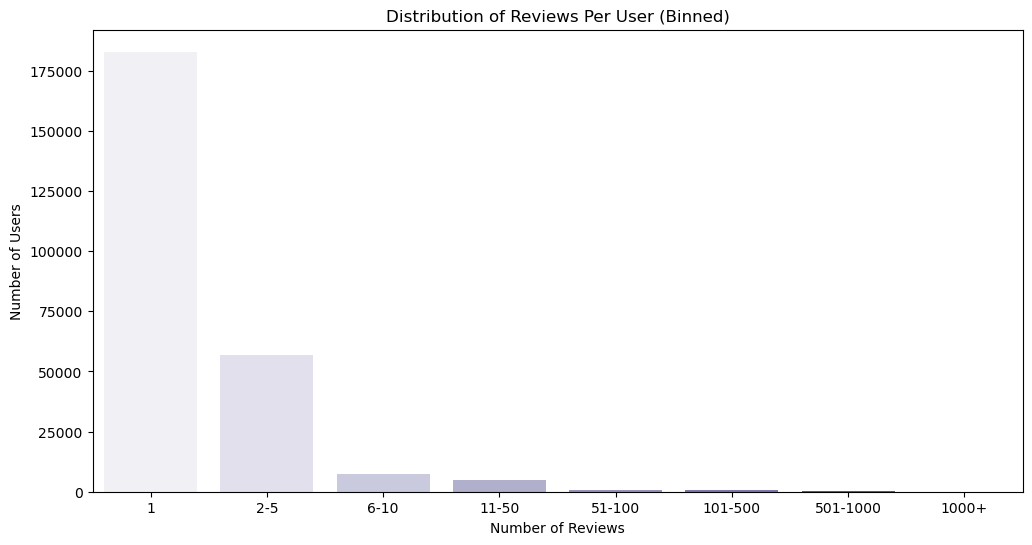

In [105]:
if 'user_id' in reviews_df.columns:
    user_reviews_count = reviews_df['user_id'].value_counts()

    # Define bins for the number of reviews
    bins = [0, 1, 5, 10, 50, 100, 500, 1000, user_reviews_count.max()]
    labels = ['1', '2-5', '6-10', '11-50', '51-100', '101-500', '501-1000', '1000+']
    
    # Create a new column for binned review counts
    user_reviews_count_bins = pd.cut(user_reviews_count, bins=bins, labels=labels, right=True)

    # Plot the distribution of users in each bin
    plt.figure(figsize=(12, 6))
    sns.countplot(x=user_reviews_count_bins, palette='Purples')

    plt.title('Distribution of Reviews Per User (Binned)')
    plt.xlabel('Number of Reviews')
    plt.ylabel('Number of Users')
    plt.show()


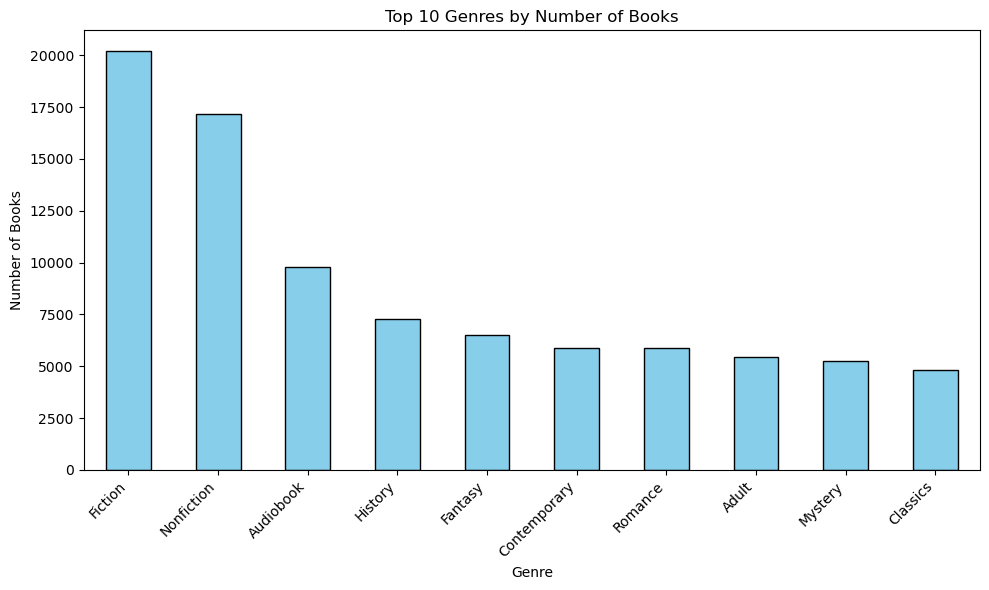

In [106]:
# top 10 genres by number of books
top_genres_by_books = books_genres_df['genre_name'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_genres_by_books.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Genres by Number of Books')
plt.xlabel('Genre')
plt.ylabel('Number of Books')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

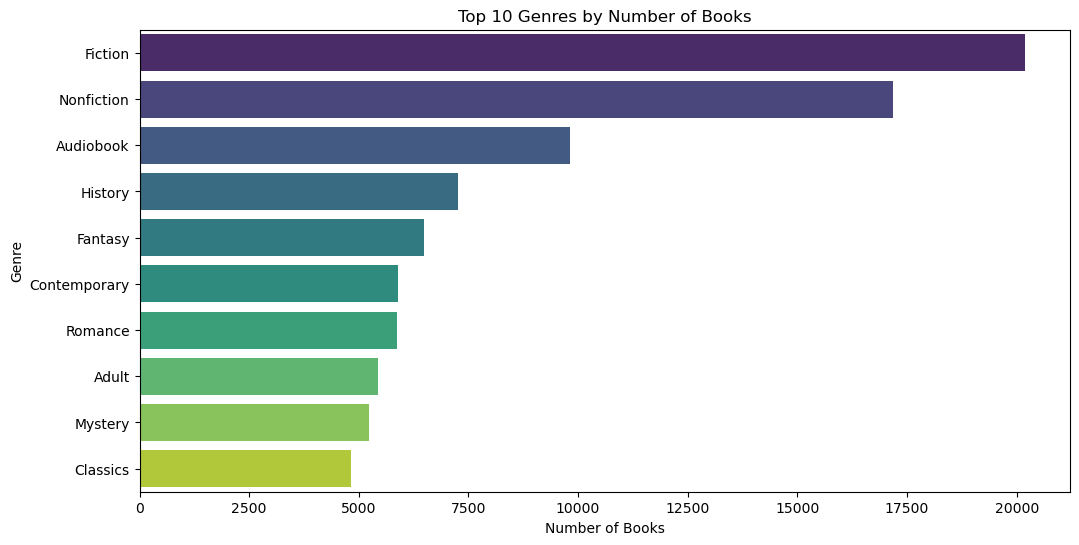

In [144]:
genre_counts = books_genres_df['genre_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 10 Genres by Number of Books')
plt.xlabel('Number of Books')
plt.ylabel('Genre')
plt.show()


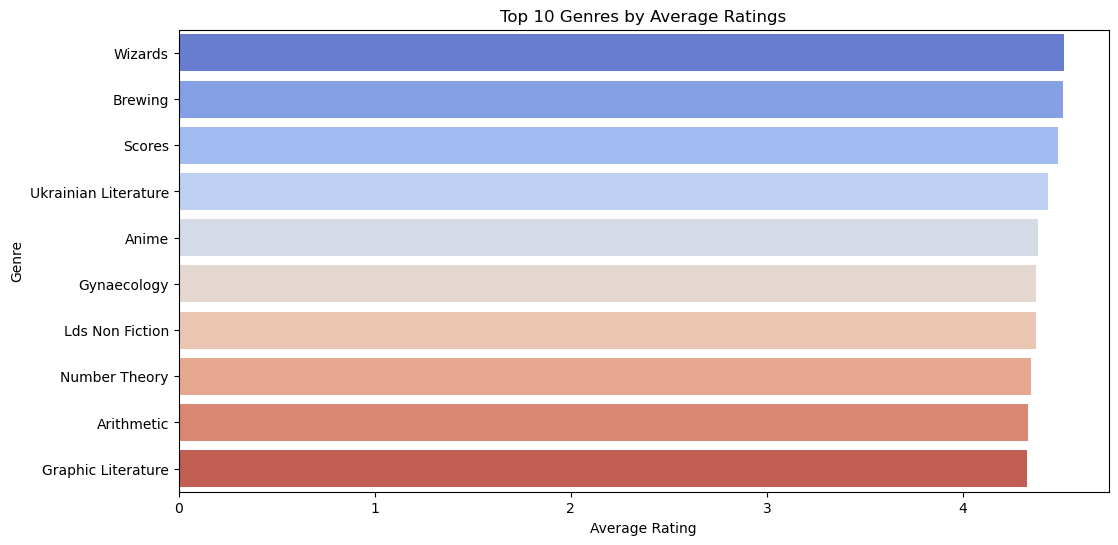

In [143]:
# merge books and genres data to associate genres with ratings
books_with_genres = pd.merge(books_df, books_genres_df, on='isbn13')

# calculate average rating per genre
genre_avg_ratings = books_with_genres.groupby('genre_name')['average_rating'].mean().sort_values(ascending=False).head(10)

# plot the top 10 genres by average ratings
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_avg_ratings.values, y=genre_avg_ratings.index, palette='coolwarm')
plt.title('Top 10 Genres by Average Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.show()


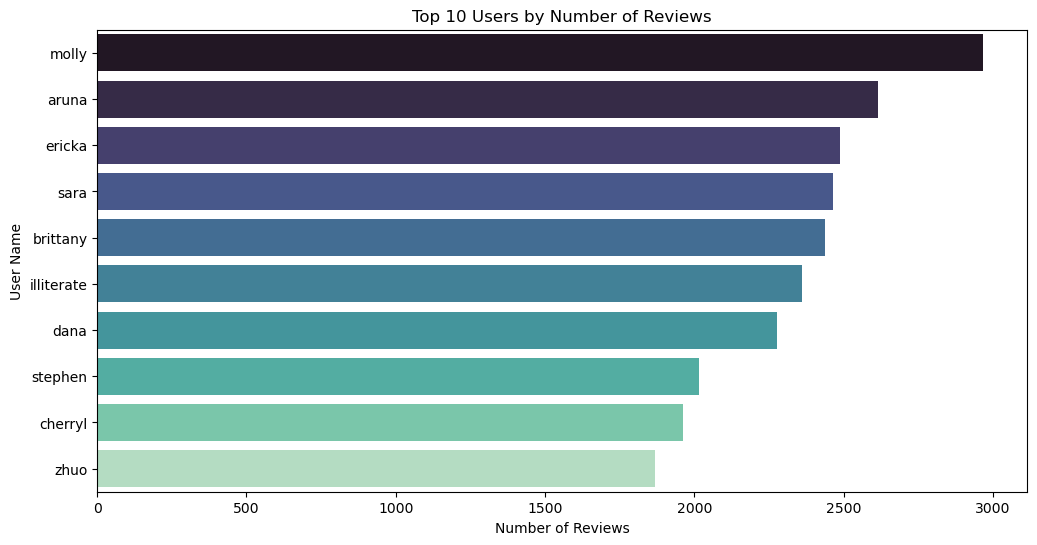

In [128]:
# top users by number of reviews
top_users = users_df.nlargest(10, 'total_reviews')

plt.figure(figsize=(12, 6))
sns.barplot(x=top_users['total_reviews'], y=top_users['name'], palette='mako')
plt.title('Top 10 Users by Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('User Name')
plt.show()


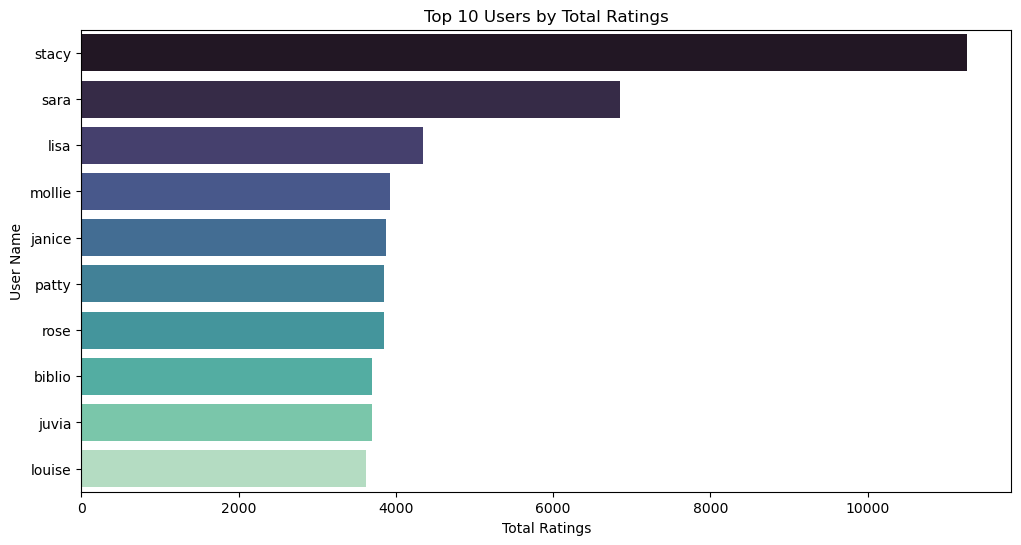

In [129]:
# top 10 users by total ratings
top_raters = users_df.nlargest(10, 'total_ratings')

plt.figure(figsize=(12, 6))
sns.barplot(x=top_raters['total_ratings'], y=top_raters['name'], palette='mako')
plt.title('Top 10 Users by Total Ratings')
plt.xlabel('Total Ratings')
plt.ylabel('User Name')
plt.show()


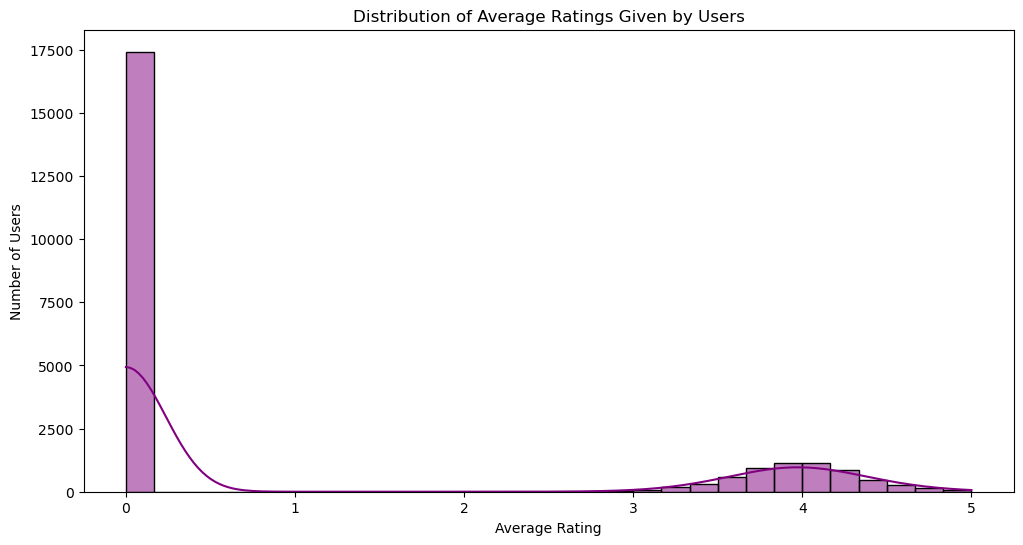

In [130]:
# distribution of average ratings given by users
plt.figure(figsize=(12, 6))
sns.histplot(users_df['avg_rating'], bins=30, kde=True, color='purple')
plt.title('Distribution of Average Ratings Given by Users')
plt.xlabel('Average Rating')
plt.ylabel('Number of Users')
plt.show()


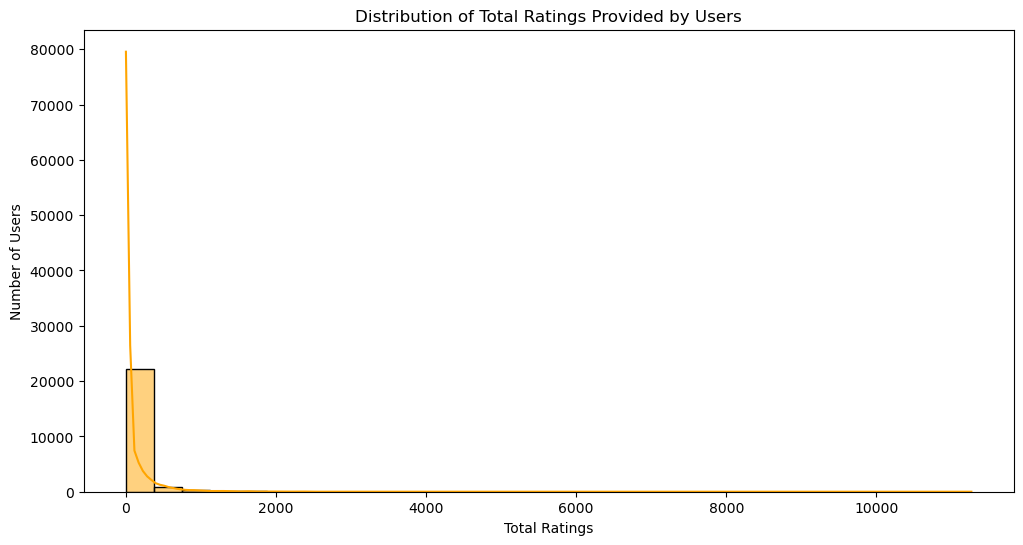

In [131]:
# distribution of total ratings given by users
plt.figure(figsize=(12, 6))
sns.histplot(users_df['total_ratings'], bins=30, kde=True, color='orange')
plt.title('Distribution of Total Ratings Provided by Users')
plt.xlabel('Total Ratings')
plt.ylabel('Number of Users')
plt.show()


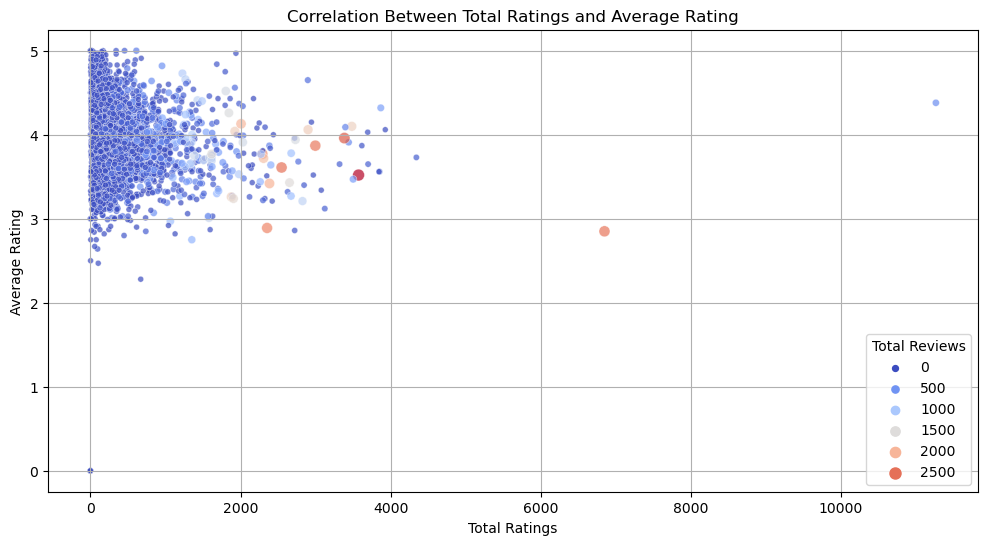

In [135]:
# scatter plot of total ratings vs. average rating
plt.figure(figsize=(12, 6))
sns.scatterplot(data=users_df, x='total_ratings', y='avg_rating', alpha=0.7, hue='total_reviews', size='total_reviews', palette='coolwarm')
plt.title('Correlation Between Total Ratings and Average Rating')
plt.xlabel('Total Ratings')
plt.ylabel('Average Rating')
plt.legend(title='Total Reviews')
plt.grid(True)
plt.show()
# analyze whether users who give more ratings tend to rate higher or lower.

In [ ]:
books_df.to_csv('./clean/new/cleaned_books_data.csv', index=False)
books_genres_df.to_csv('./clean/new/cleaned_books_genres_data.csv', index=False)
reviews_df.to_csv('./clean/new/cleaned_reviews_data.csv', index=False)
series_df.to_csv('./clean/new/cleaned_series_data.csv', index=False)
users_df.to_csv('./clean/new/cleaned_users_data.csv', index=False)